# Model Updates

In [1]:
import pandas as pd

methods = [
("Random", "RND"),
("Displacement", "DSP"),
("DINO", "DINO"),
]
snapshots = ["Snapshot125", "Snapshot150"]
train_evals = [("Train15_Eval17", 17), ("Train17_Eval15", 15)]
frame_counts = [20, 35, 50]

rows = []
for method_name, method_tag in methods:
    for snapshot in snapshots:
        snap_tag = "S125" if snapshot == "Snapshot125" else "S150"
        for train_eval, eval_trial in train_evals:
            split_tag = "T15E17" if train_eval == "Train15_Eval17" else "T17E15"
            truth_csv = "Trial17 truth" if eval_trial == 17 else "Trial15 truth"
            for frame_count in frame_counts:
                run_id = f"{method_tag}{snap_tag}{split_tag}_F{frame_count}"
                rows.append(
                {
                "run_id": run_id,
                "method": method_name,
                "snapshot": snapshot,
                "train_eval": train_eval,
                "eval_trial": eval_trial,
                "frame_count": frame_count,
                "epochs": 100,
                "head_only": True,
                "seed": 42,
                "subset_csv": "",
                "truth_csv": truth_csv,
                "status": "planned",
                "mean_err_all": pd.NA,
                "delta_vs_baseline": pd.NA,
                "notes": "",
                }
                )

run_table_df = pd.DataFrame(rows).sort_values(
["method", "snapshot", "train_eval", "frame_count"]
).reset_index(drop=True)

output_csv = "run_table_template.csv"
run_table_df.to_csv(output_csv, index=False)

print(f"Saved: {output_csv} | rows={len(run_table_df)}")
loaded_df = pd.read_csv(output_csv)
print(loaded_df)



Saved: run_table_template.csv | rows=36
                run_id        method     snapshot      train_eval  eval_trial  \
0   DINOS125T15E17_F20          DINO  Snapshot125  Train15_Eval17          17   
1   DINOS125T15E17_F35          DINO  Snapshot125  Train15_Eval17          17   
2   DINOS125T15E17_F50          DINO  Snapshot125  Train15_Eval17          17   
3   DINOS125T17E15_F20          DINO  Snapshot125  Train17_Eval15          15   
4   DINOS125T17E15_F35          DINO  Snapshot125  Train17_Eval15          15   
5   DINOS125T17E15_F50          DINO  Snapshot125  Train17_Eval15          15   
6   DINOS150T15E17_F20          DINO  Snapshot150  Train15_Eval17          17   
7   DINOS150T15E17_F35          DINO  Snapshot150  Train15_Eval17          17   
8   DINOS150T15E17_F50          DINO  Snapshot150  Train15_Eval17          17   
9   DINOS150T17E15_F20          DINO  Snapshot150  Train17_Eval15          15   
10  DINOS150T17E15_F35          DINO  Snapshot150  Train17_Eval15    

In [5]:
For_Test_50_Eval15 = loaded_df[(loaded_df["frame_count"] == 50) & (loaded_df["eval_trial"] == 15)]
print(For_Test_50_Eval15)

                run_id        method     snapshot      train_eval  eval_trial  \
5   DINOS125T17E15_F50          DINO  Snapshot125  Train17_Eval15          15   
11  DINOS150T17E15_F50          DINO  Snapshot150  Train17_Eval15          15   
17   DSPS125T17E15_F50  Displacement  Snapshot125  Train17_Eval15          15   
23   DSPS150T17E15_F50  Displacement  Snapshot150  Train17_Eval15          15   
29   RNDS125T17E15_F50        Random  Snapshot125  Train17_Eval15          15   
35   RNDS150T17E15_F50        Random  Snapshot150  Train17_Eval15          15   

    frame_count  epochs  head_only  seed  subset_csv      truth_csv   status  \
5            50     100       True    42         NaN  Trial15 truth  planned   
11           50     100       True    42         NaN  Trial15 truth  planned   
17           50     100       True    42         NaN  Trial15 truth  planned   
23           50     100       True    42         NaN  Trial15 truth  planned   
29           50     100       Tr

In [33]:
from pathlib import Path
import torch
import deeplabcut
import DLCsupport as dlcs
import deeplabcut as dlc
import matplotlib.pyplot as plt



In [23]:
from pathlib import Path
import re
import shutil
import pandas as pd
import DLCsupport as dlcs

# Source trial with Cam1/Cam2 and CSVs
src_trial = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity\Snapshot150\Train17_Eval15"
)

# 1) Ensure we have a real DLC project config.yaml to write labeled-data into
# Replace dummy_video with any existing video file you already use for project init.
combined_config = dlcs.create_combined_project_if_missing(
    task="Canari",
    experimenter="Tyler_Finetune",
    combined_project_root=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity\Snapshot150\Train17_Eval15"
    ),
    dummy_video=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17\cam1.avi"
    ),
)

# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"DavidBowie": [combined_config]},
        strict=True,
    )

# 2) Build a clean trial folder for xma_to_dlc
work_root = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\_tmp_clean_trials"
)
clean_trial = work_root / "Train17_Eval15"
clean_trial.mkdir(parents=True, exist_ok=True)

# Copy camera folders
for cam_folder in ["Cam1", "Cam2"]:
    src = src_trial / cam_folder
    dst = clean_trial / cam_folder
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

# Pick truth CSV and keep only coordinate columns
truth_csv = src_trial / "Predicted15_Snapshot150-TruthSubset.csv"
df = pd.read_csv(truth_csv)

coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
clean_df = df[coord_cols]

# Name contains 2Dpoints so xrommtools picks it first
clean_points_csv = clean_trial / "Train17_Eval15-2Dpoints.csv"
clean_df.to_csv(clean_points_csv, index=False)

# 3) Build dataset from cleaned trial
dlcs.build_combined_dataset(
    combined_config=combined_config,      # real config.yaml path
    data_path=clean_trial,                # folder containing csv + Cam1 + Cam2
    dataset_name="For_Test_50_Eval15",
    experimenter="Tyler",
    nframes=50,
    frame_selection_seed=42,
)

Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity\Snapshot150\Train17_Eval15\Canari-Tyler_Finetune-2026-05-27\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity\Snapshot150\Train17_Eval15\Canari-Tyler_Finetune-2026-05-27\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity\Snapshot150\Train17_Eval15\Canari-Tyler_Finetune-2026-05-27\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity\Snapshot150\Train17_Eval15\Canari-Tyler_Finetune-2026-05-27\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architecture?): copyin

In [24]:
# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"DavidBowie": [combined_config]},
        strict=True,
    )


In [25]:
# 3) Keep transfer learning from old model weights
snapshot_path = (
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T17\Canari-Tyler-2026-04-22\dlc-models-pytorch\iteration-0\CanariApr22-trainset95shuffle1\train\snapshot-150.pt"
)

dlcs.create_and_train(
    config_path=combined_config,
    epochs=60,
    snapshot_path=snapshot_path
)

Updated scorer in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity\Snapshot150\Train17_Eval15\Canari-Tyler_Finetune-2026-05-27\config.yaml from 'Tyler_Finetune' to 'Tyler'
INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead
Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: C:\Users\Salle-Cineradio\Documents\

C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity\Snapshot150\Train17_Eval15\Canari-Tyler_Finetune-2026-05-27\labeled-data\Cam1\CollectedData_Tyler.h5  not found (perhaps not annotated).
Annotation data was not found by splitting video paths (from config['video_sets']). An alternative route is taken...
The following folders were found: ['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\SamplesForModelUpdate\\DisplacementDiversity\\Snapshot150\\Train17_Eval15\\Canari-Tyler_Finetune-2026-05-27\\labeled-data\\Cam1', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\SamplesForModelUpdate\\DisplacementDiversity\\Snapshot150\\Train17_Eval15\\Canari-Tyler_Finetune-2026-05-27\\labeled-data\\For_Test_50_Eval15']
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\

    type: ResNet
    model_name: resnet50_gn
    output_stride: 16
    freeze_bn_stats: False
    freeze_bn_weights: False
  backbone_output_channels: 2048
  heads:
    bodypart:
      type: HeatmapHead
      weight_init: normal
      predictor:
        type: HeatmapPredictor
        apply_sigmoid: False
        clip_scores: True
        location_refinement: True
        locref_std: 7.2801
      target_generator:
        type: HeatmapGaussianGenerator
        num_heatmaps: 21
        pos_dist_thresh: 17
        heatmap_mode: KEYPOINT
        gradient_masking: False
        generate_locref: True
        locref_std: 7.2801
      criterion:
        heatmap:
          type: WeightedMSECriterion
          weight: 1.0
        locref:
          type: WeightedHuberCriterion
          weight: 0.05
      heatmap_config:
        channels: [2048, 21]
        kernel_size: [3]
        strides: [2]
      locref_config:
        channels: [2048, 42]
        kernel_size: [3]
        strides: [2]
net_typ

FileNotFoundError: No snapshots found under pattern: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity\Snapshot150\Train17_Eval15\Canari-Tyler_Finetune-2026-05-27\dlc-models-pytorch\iteration-0\*\train\snapshots\snapshot-*.pt

In [26]:
from pathlib import Path
import glob
import re

project_dir = Path(combined_config).parent
p1 = project_dir / "dlc-models-pytorch" / "iteration-0" / "*" / "train" / "snapshot-*.pt"
p2 = project_dir / "dlc-models-pytorch" / "iteration-0" / "*" / "train" / "snapshots" / "snapshot-*.pt"

snaps = glob.glob(str(p1)) + glob.glob(str(p2))
if not snaps:
    raise FileNotFoundError("No snapshot files found in either train layout.")

def epoch_key(path):
    m = re.search(r"snapshot(?:-best)?-(\d+)\.pt$", path.replace("\\", "/"))
    return int(m.group(1)) if m else -1

latest_snapshot = sorted(snaps, key=epoch_key)[-1]
print("Latest snapshot:", latest_snapshot)

Latest snapshot: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity\Snapshot150\Train17_Eval15\Canari-Tyler_Finetune-2026-05-27\dlc-models-pytorch\iteration-0\CanariMay27-trainset95shuffle1\train\snapshot-210.pt


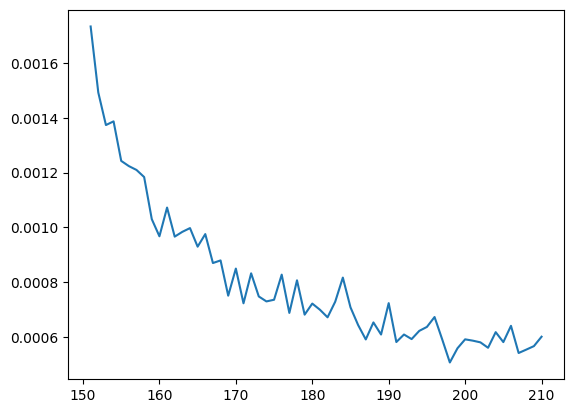

In [34]:
# plot learning stats
learning_stats = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity\Snapshot150\Train17_Eval15\Canari-Tyler_Finetune-2026-05-27\dlc-models-pytorch\iteration-0\CanariMay27-trainset95shuffle1\train\learning_stats.csv")
learning_stats.head()
plt.plot(learning_stats["step"], learning_stats["losses/train.total_loss"], label="train_loss")

In [35]:
# the model to predict on trial 15
model_path = latest_snapshot
import deeplabcut as dlc
dlc.analyze_videos(
    str(combined_config),
    [str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\db_cam1.avi")), str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\db_cam2.avi"))],
    save_as_csv=True,
    destfolder=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\DavidBowie_20250828_F15"
)

Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity\Snapshot150\Train17_Eval15\Canari-Tyler_Finetune-2026-05-27\dlc-models-pytorch\iteration-0\CanariMay27-trainset95shuffle1\train\snapshot-210.pt
Using scorer: DLC_Resnet50_CanariMay27shuffle1_snapshot_210
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\db_cam2.avi
Video metadata: 
  Overall # of frames:    2980
  Duration of video [s]:  99.33
  fps:                    30.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 2980/2980 [03:48<00:00, 13.06it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\DavidBowie_20250828_F15\db_cam2DLC_Resnet50_CanariMay27shuffle1_snapshot_210.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\DavidBowie_20250828_F15\db_cam2DLC_Resnet50_CanariMay27shuffle1_snapshot_210_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\db_cam1.avi
Video metadata: 
  Overall # of frames:    2980
  Duration of video [s]:  99.33
  fps:                    30.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 2980/2980 [03:52<00:00, 12.83it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\DavidBowie_20250828_F15\db_cam1DLC_Resnet50_CanariMay27shuffle1_snapshot_210.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\DavidBowie_20250828_F15\db_cam1DLC_Resnet50_CanariMay27shuffle1_snapshot_210_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_CanariMay27shuffle1_snapshot_210'

In [21]:
import xrommtools as xt

In [36]:
xt.dlc_to_xma(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\DavidBowie_20250828_F15\db_cam1DLC_Resnet50_CanariMay27shuffle1_snapshot_210.csv", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\DavidBowie_20250828_F15\db_cam2DLC_Resnet50_CanariMay27shuffle1_snapshot_210.csv", 
    "ModelUpdate", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\DavidBowie_20250828_F15")

In [37]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import shutil
import glob

import DLCsupport as dlcs

ROOT = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate")

METHOD_DIRS = {
    "DINO": "DinoDiversity",
    "Displacement": "DisplacementDiversity",
    "Random": "RandomFrames",
}

SNAPSHOTS = ["Snapshot125", "Snapshot150"]
SPLITS = ["Train15_Eval17", "Train17_Eval15"]

NFRAMES = 50
SEED = 42
EPOCHS = 60
RUN_TRAINING = True

# Any existing video file is fine for project creation
DUMMY_VIDEO = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17\cam1.avi"
)

# Base model config by training split
BASE_CONFIG_BY_SPLIT = {
    "Train15_Eval17": Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n400_T15\Canari-Tyler-2026-04-24\config.yaml"
    ),
    "Train17_Eval15": Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n400_T17\Canari-Tyler-2026-04-22\config.yaml"
    ),
}

In [ ]:
def find_truth_subset_csv(split_folder: Path) -> Path:
    hits = sorted(split_folder.glob("*-TruthSubset.csv"))
    if len(hits) != 1:
        raise ValueError(f"Expected exactly 1 TruthSubset CSV in {split_folder}, found {len(hits)}")
    return hits[0]

def resolve_source_snapshot(split_name: str, snapshot_name: str) -> str:
    base_cfg = BASE_CONFIG_BY_SPLIT[split_name]
    train_dir_glob = base_cfg.parent / "dlc-models-pytorch" / "iteration-0" / "*" / "train"
    train_dirs = sorted(glob.glob(str(train_dir_glob)))
    if not train_dirs:
        raise FileNotFoundError(f"No train dir found for base config: {base_cfg}")
    train_dir = Path(train_dirs[-1])
    snap_num = "125" if snapshot_name == "Snapshot125" else "150"
    snap = train_dir / f"snapshot-{snap_num}.pt"
    if not snap.exists():
        raise FileNotFoundError(f"Missing source snapshot: {snap}")
    return str(snap)

def latest_snapshot_for_project(config_path: Path) -> str:
    p = config_path.parent
    g1 = p / "dlc-models-pytorch" / "iteration-0" / "*" / "train" / "snapshot-*.pt"
    g2 = p / "dlc-models-pytorch" / "iteration-0" / "*" / "train" / "snapshots" / "snapshot-*.pt"
    snaps = glob.glob(str(g1)) + glob.glob(str(g2))
    if not snaps:
        raise FileNotFoundError(f"No snapshots found under {p}")
    def epoch_key(path: str) -> int:
        m = re.search(r"snapshot(?:-best)?-(\d+)\.pt$", path.replace("\\", "/"))
        return int(m.group(1)) if m else -1
    return sorted(snaps, key=epoch_key)[-1]

def prepare_clean_trial(split_folder: Path, run_tag: str) -> Path:
    clean_root = split_folder / "_build" / run_tag / "clean_trial"
    if clean_root.exists():
        shutil.rmtree(clean_root)
    clean_root.mkdir(parents=True, exist_ok=True)

    for cam in ["Cam1", "Cam2"]:
        src = split_folder / cam
        dst = clean_root / cam
        if not src.exists():
            raise FileNotFoundError(f"Missing camera folder: {src}")
        shutil.copytree(src, dst)

    truth_csv = find_truth_subset_csv(split_folder)
    df = pd.read_csv(truth_csv)
    coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
    if not coord_cols:
        raise ValueError(f"No coordinate columns found in {truth_csv}")
    df[coord_cols].to_csv(clean_root / f"{run_tag}-2Dpoints.csv", index=False)
    return clean_root

def resolve_split_folder(root: Path, method_dir: str, snapshot_name: str, split_name: str) -> Path:
    # Current layout: method/snapshot/split
    p_current = root / method_dir / snapshot_name / split_name

    # Future layout: method/split/snapshot
    p_future = root / method_dir / split_name / snapshot_name

    existing = [p for p in [p_current, p_future] if p.exists()]

    if len(existing) == 0:
        raise FileNotFoundError(
            f"No matching folder for method={method_dir}, snapshot={snapshot_name}, split={split_name}. "
            f"Tried: {p_current} and {p_future}"
        )
    if len(existing) > 1:
        raise RuntimeError(
            f"Ambiguous layout: both paths exist for method={method_dir}, snapshot={snapshot_name}, split={split_name}: "
            f"{existing}"
        )
    return existing[0]

In [41]:
def run_one_instance(method_name: str, snapshot_name: str, split_name: str) -> dict:
    method_folder = ROOT / METHOD_DIRS[method_name]
    split_folder = method_folder / snapshot_name / split_name

    if not split_folder.exists():
        raise FileNotFoundError(f"Missing split folder: {split_folder}")

    run_tag = f"{method_name}_{snapshot_name}_{split_name}_F{NFRAMES}_S{SEED}"

    # Keep every artifact inside this exact split folder
    project_root = split_folder / "_projects"
    dataset_name = run_tag

    clean_trial = prepare_clean_trial(split_folder, run_tag)

    combined_config = dlcs.create_combined_project_if_missing(
        task="Canari",
        experimenter="Tyler_Finetune",
        combined_project_root=project_root,
        dummy_video=DUMMY_VIDEO,
    )

    # Ensure bodyparts schema matches DavidBowie
    _ = dlcs.apply_bird_bodyparts_to_configs(
        {"DavidBowie": [combined_config]},
        strict=True,
    )

    # Avoid mixing old and new labeled-data for same dataset_name
    ds_folder = Path(combined_config).parent / "labeled-data" / dataset_name
    if ds_folder.exists():
        shutil.rmtree(ds_folder)

    dlcs.build_combined_dataset(
        combined_config=combined_config,
        data_path=clean_trial,
        dataset_name=dataset_name,
        experimenter="Tyler",
        nframes=NFRAMES,
        frame_selection_seed=SEED,
    )

    source_snapshot = resolve_source_snapshot(split_name, snapshot_name)

    trained_snapshot = None
    if RUN_TRAINING:
        try:
            trained_snapshot = dlcs.create_and_train(
                config_path=combined_config,
                epochs=1,
                snapshot_path=source_snapshot,
            )
        except FileNotFoundError:
            trained_snapshot = latest_snapshot_for_project(Path(combined_config))

    return {
        "method": method_name,
        "snapshot": snapshot_name,
        "split": split_name,
        "split_folder": str(split_folder),
        "combined_config": str(combined_config),
        "dataset_name": dataset_name,
        "clean_trial": str(clean_trial),
        "source_snapshot": source_snapshot,
        "trained_snapshot": trained_snapshot if trained_snapshot else "",
        "status": "ok",
    }


In [42]:
records = []

for method_name in METHOD_DIRS.keys():
    for snapshot_name in SNAPSHOTS:
        for split_name in SPLITS:
            try:
                rec = run_one_instance(method_name, snapshot_name, split_name)
            except Exception as e:
                rec = {
                    "method": method_name,
                    "snapshot": snapshot_name,
                    "split": split_name,
                    "status": "error",
                    "error": str(e),
                }
            records.append(rec)
            print(rec["method"], rec["snapshot"], rec["split"], "->", rec["status"])

manifest_df = pd.DataFrame(records)

manifest_path = ROOT / "_manifests" / f"model_update_manifest_F{NFRAMES}_S{SEED}.csv"
manifest_path.parent.mkdir(parents=True, exist_ok=True)
manifest_df.to_csv(manifest_path, index=False)

print("Saved manifest:", manifest_path)
display(manifest_df)

Reusing existing combined project: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DinoDiversity\Snapshot125\Train17_Eval15\_projects\Canari-Tyler_Finetune-2026-05-27\config.yaml
Using xrommtools_copy.xma_to_dlc for dataset build
Frame selection seed set to 42


DINO Snapshot125 Train15_Eval17 -> error
Using trial folders: ['clean_trial']
Extracting camera 1 trial images and 2D points...
Extracting camera 2 trial images and 2D points...


Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


...done.
Training data extracted to projectpath/labeled-data. Now use deeplabcut.create_training_dataset
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DinoDiversity\Snapshot125\Train17_Eval15\_projects\Canari-Tyler_Finetune-2026-05-27\labeled-data\Cam1\CollectedData_Tyler.h5  not found (perhaps not annotated).
Annotation data was not found by splitting video paths (from config['video_sets']). An alternative route is taken...
The following folders were found: ['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\SamplesForModelUpdate\\DinoDiversity\\Snapshot125\\Train17_Eval15\\_projects\\Canari-Tyler_Finetune-2026-05-27\\labeled-data\\Cam1', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\SamplesForModelUpdate\\DinoDiversity\\Snapshot125\\Train17_Eval15\\_projects\\Canari-Tyler_Finetune-2026-05-27\\labeled

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DinoDiversity\Snapshot125\Train17_Eval15\_projects\Canari-Tyler_Finetune-2026-05-27
  pose_config_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DinoDiversity\Snapshot125\Train17_Eval15\_projects\Canari-Tyler_Finetun

...

Updated scorer in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\RandomFrames\Snapshot150\Train17_Eval15\_projects\Canari-Tyler_Finetune-2026-05-27\config.yaml from 'Tyler_Finetune' to 'Tyler'
INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


...done.
Training data extracted to projectpath/labeled-data. Now use deeplabcut.create_training_dataset
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\RandomFrames\Snapshot150\Train17_Eval15\_projects\Canari-Tyler_Finetune-2026-05-27\labeled-data\Cam1\CollectedData_Tyler.h5  not found (perhaps not annotated).
Annotation data was not found by splitting video paths (from config['video_sets']). An alternative route is taken...
The following folders were found: ['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\SamplesForModelUpdate\\RandomFrames\\Snapshot150\\Train17_Eval15\\_projects\\Canari-Tyler_Finetune-2026-05-27\\labeled-data\\Cam1', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\SamplesForModelUpdate\\RandomFrames\\Snapshot150\\Train17_Eval15\\_projects\\Canari-Tyler_Finetune-2026-05-27\\labeled-da

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\RandomFrames\Snapshot150\Train17_Eval15\_projects\Canari-Tyler_Finetune-2026-05-27
  pose_config_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\RandomFrames\Snapshot150\Train17_Eval15\_projects\Canari-Tyler_Finetune-

Random Snapshot150 Train17_Eval15 -> ok
Saved manifest: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\_manifests\model_update_manifest_F50_S42.csv


,method,snapshot,split,status,error,split_folder,combined_config,dataset_name,clean_trial,source_snapshot,trained_snapshot
0,DINO,Snapshot125,Train15_Eval17,error,Missing camera folder: C:\Users\Salle-Cineradi...,NaN,NaN,NaN,NaN,NaN,NaN
1,DINO,Snapshot125,Train17_Eval15,ok,NaN,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,DINO_Snapshot125_Train17_Eval15_F50_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...
2,DINO,Snapshot150,Train15_Eval17,error,Missing camera folder: C:\Users\Salle-Cineradi...,NaN,NaN,NaN,NaN,NaN,NaN
3,DINO,Snapshot150,Train17_Eval15,ok,NaN,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,DINO_Snapshot150_Train17_Eval15_F50_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...
4,Displacement,Snapshot125,Train15_Eval17,error,No readable frames found for clean_trial camer...,NaN,NaN,NaN,NaN,NaN,NaN
5,Displacement,Snapshot125,Train17_Eval15,ok,NaN,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,Displacement_Snapshot125_Train17_Eval15_F50_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...
6,Displacement,Snapshot150,Train15_Eval17,error,No readable frames found for clean_trial camer...,NaN,NaN,NaN,NaN,NaN,NaN
7,Displacement,Snapshot150,Train17_Eval15,ok,NaN,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,Displacement_Snapshot150_Train17_Eval15_F50_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...
8,Random,Snapshot125,Train15_Eval17,error,No columns to parse from file,NaN,NaN,NaN,NaN,NaN,NaN
9,Random,Snapshot125,Train17_Eval15,ok,NaN,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,Random_Snapshot125_Train17_Eval15_F50_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...


In [ ]:
bad_rows = []
for _, r in manifest_df[manifest_df["status"] == "ok"].iterrows():
    sf = Path(r["split_folder"]).resolve()
    cc = Path(r["combined_config"]).resolve()
    ct = Path(r["clean_trial"]).resolve()
    if sf not in cc.parents:
        bad_rows.append(("combined_config", str(cc), str(sf)))
    if sf not in ct.parents:
        bad_rows.append(("clean_trial", str(ct), str(sf)))

if bad_rows:
    print("Placement issues found:")
    for b in bad_rows:
        print(b)
else:
    print("All outputs are placed inside each source split folder.")